In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("amazon.xlsx")
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [4]:
print("Rows, Columns :", df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nStatistical Summary")
print(df.describe())

Rows, Columns : (100000, 20)

Column Names
Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

Data Types
OrderID                  object
OrderDate        datetime64[ns]
CustomerID               object
CustomerName             object
ProductID                object
ProductName              object
Category                 object
Brand                    object
Quantity                  int64
UnitPrice               float64
Discount                float64
Tax                     float64
ShippingCost            float64
TotalAmount             float64
PaymentMethod            object
OrderStatus              object
City                     object
State                    object
Country                  object
SellerID                 object
dtyp

In [6]:
#KPIs
print("Total Sales :", df['TotalAmount'].sum())

print("Total Orders :", df['OrderID'].nunique())

print("Average Sales :", df['TotalAmount'].mean())

print("Maximum Sales :", df['TotalAmount'].max())

print("Minimum Sales :", df['TotalAmount'].min())

Total Sales : 91825647.92
Total Orders : 100000
Average Sales : 918.2564792000001
Maximum Sales : 3534.98
Minimum Sales : 4.27


In [7]:
#Sales by State
sales_state = df.groupby('State')['TotalAmount'].sum().sort_values(ascending=False)

print(sales_state)

State
TX    22862540.54
CA    18231196.79
NC     4747701.73
WA     4660962.17
PA     4650673.88
CO     4638498.97
IL     4632847.44
OH     4615442.32
IN     4609048.43
FL     4597177.27
NY     4554358.08
DC     4520876.11
AZ     4504324.19
Name: TotalAmount, dtype: float64


In [8]:
#Sales by Category
sales_category = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)

print(sales_category)

Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Home & Kitchen       15163939.36
Name: TotalAmount, dtype: float64


In [9]:
#Sales by Product
sales_product = df.groupby('ProductName')['TotalAmount'].sum().sort_values(ascending=False)

print(sales_product)

ProductName
Memory Card 128GB              1935138.40
LED Desk Lamp                  1921948.41
Mechanical Keyboard            1906963.54
Electric Kettle                1905751.79
Smartwatch                     1901275.59
Dress Shirt                    1896765.36
Water Bottle                   1895467.95
Gaming Mouse                   1895103.98
Kids Toy Car                   1891082.43
Jeans                          1882591.82
Noise Cancelling Headphones    1881108.57
Cookware Set                   1877038.73
Smartphone Case                1875421.41
Microphone                     1871740.68
Smart Light Bulb               1868940.58
4K Monitor                     1866774.35
Phone Tripod                   1866256.31
Board Game                     1863310.96
Vacuum Cleaner                 1855117.83
Router                         1850756.20
Laptop Sleeve                  1848297.80
Yoga Mat                       1847898.09
HDMI Cable 2m                  1847856.25
Desk Organizer        

In [10]:
#Top 5 Customers
top_customers = df.groupby('CustomerName')['TotalAmount'].sum().sort_values(ascending=False).head(5)

print(top_customers)

CustomerName
Pooja Kapoor    547832.64
Vihaan Singh    526675.89
Pooja Singh     516451.45
Kabir Joshi     515361.68
Aditya Gupta    515005.09
Name: TotalAmount, dtype: float64


In [11]:
#Quantity Sold
quantity = df.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False)

print(quantity)

ProductName
LED Desk Lamp                  6344
Water Bottle                   6275
Memory Card 128GB              6240
Router                         6202
Board Game                     6200
Microphone                     6196
Gaming Mouse                   6170
Electric Kettle                6165
Mechanical Keyboard            6161
Vacuum Cleaner                 6139
Kids Toy Car                   6131
Smart Light Bulb               6131
Cookware Set                   6130
4K Monitor                     6111
Action Camera                  6104
Noise Cancelling Headphones    6091
Desk Organizer                 6079
Wireless Charger               6079
Yoga Mat                       6077
Smartphone Case                6060
Jeans                          6037
Instant Pot                    6016
Wireless Earbuds               6008
Webcam Full HD                 6002
Office Chair                   5998
Portable SSD 1TB               5996
Laptop Sleeve                  5992
HDMI Cable 2m   

In [12]:
#Payment Method
payment = df['PaymentMethod'].value_counts()

print(payment)

PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: count, dtype: int64


In [13]:
#Monthly Sales Trend
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

df['Month'] = df['OrderDate'].dt.strftime('%Y-%m')

monthly_sales = df.groupby('Month')['TotalAmount'].sum()

print(monthly_sales)

Month
2020-01    1637069.40
2020-02    1339388.21
2020-03    1587125.66
2020-04    1588347.29
2020-05    1533834.17
2020-06    1500269.29
2020-07    1552981.94
2020-08    1640874.93
2020-09    1554682.21
2020-10    1515403.62
2020-11    1502232.24
2020-12    1577655.06
2021-01    1575253.23
2021-02    1425365.99
2021-03    1484165.89
2021-04    1470885.02
2021-05    1571842.25
2021-06    1593398.08
2021-07    1596668.40
2021-08    1545324.30
2021-09    1534912.30
2021-10    1511118.44
2021-11    1419480.77
2021-12    1520160.14
2022-01    1609759.87
2022-02    1369866.29
2022-03    1589809.35
2022-04    1515497.24
2022-05    1527845.26
2022-06    1533829.81
2022-07    1556516.29
2022-08    1541701.50
2022-09    1457859.60
2022-10    1534349.51
2022-11    1525937.46
2022-12    1604276.23
2023-01    1567772.07
2023-02    1384957.09
2023-03    1557146.56
2023-04    1560322.12
2023-05    1588151.65
2023-06    1485367.09
2023-07    1562298.78
2023-08    1585424.79
2023-09    1543306.82
2023

In [14]:
#State & Category Analysis
state_category = df.groupby(['State','Category'])['TotalAmount'].sum()

print(state_category)

State  Category         
AZ     Books                793211.33
       Clothing             691249.82
       Electronics          747955.37
       Home & Kitchen       737616.34
       Sports & Outdoors    694318.06
                              ...    
WA     Clothing             747668.70
       Electronics          879580.90
       Home & Kitchen       809448.28
       Sports & Outdoors    807282.60
       Toys & Games         711514.12
Name: TotalAmount, Length: 78, dtype: float64


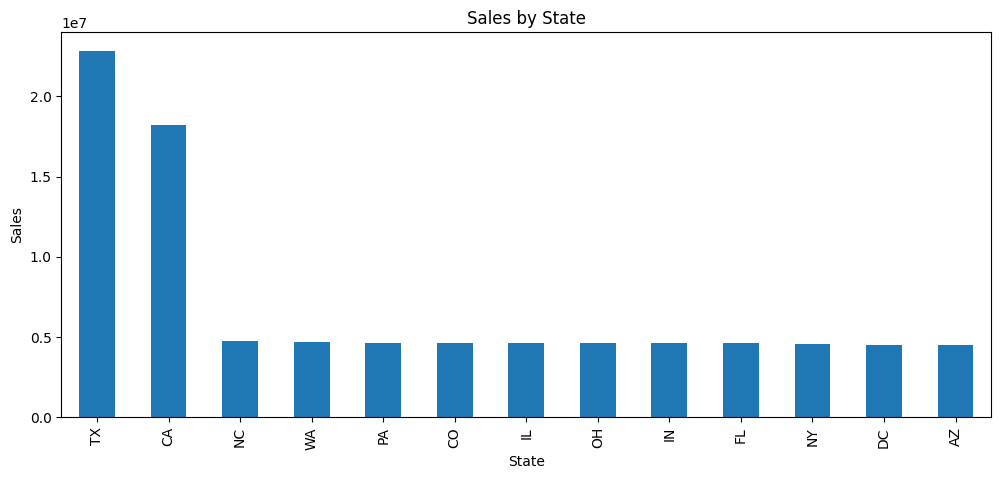

In [15]:
#Bar Chart (Sales by State)
sales_state.plot(kind='bar', figsize=(12,5))

plt.title("Sales by State")
plt.xlabel("State")
plt.ylabel("Sales")

plt.show()

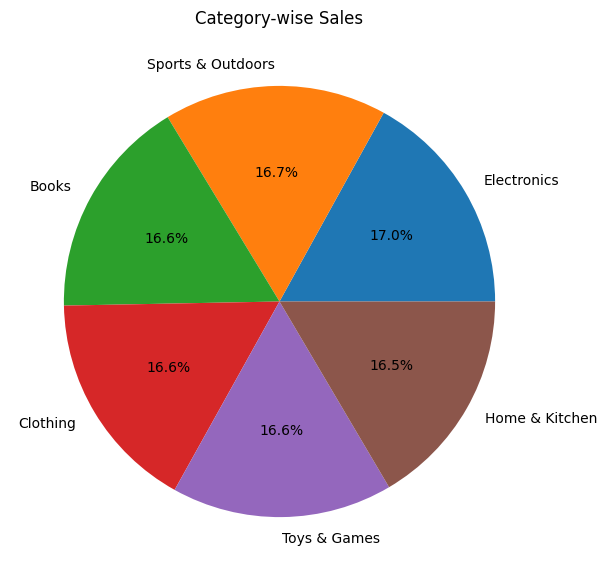

In [16]:
#Pie Chart (Category Sales)
sales_category.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.ylabel("")
plt.title("Category-wise Sales")

plt.show()

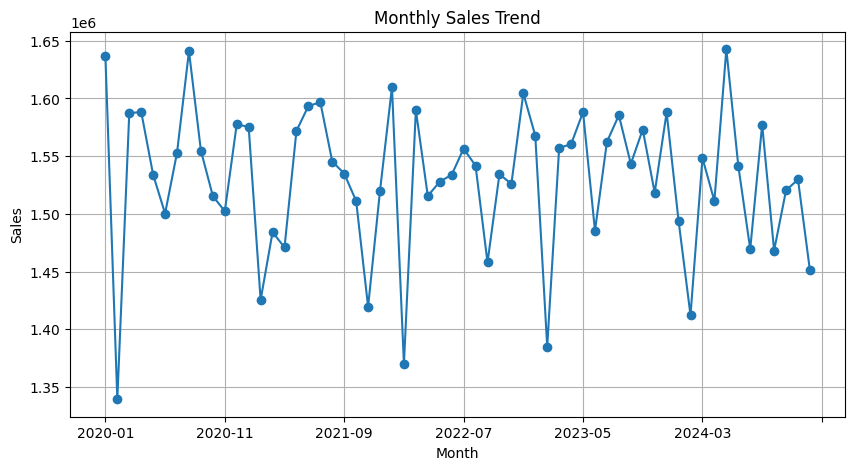

In [17]:
#Line Chart (Monthly Sales)
monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid()

plt.show()

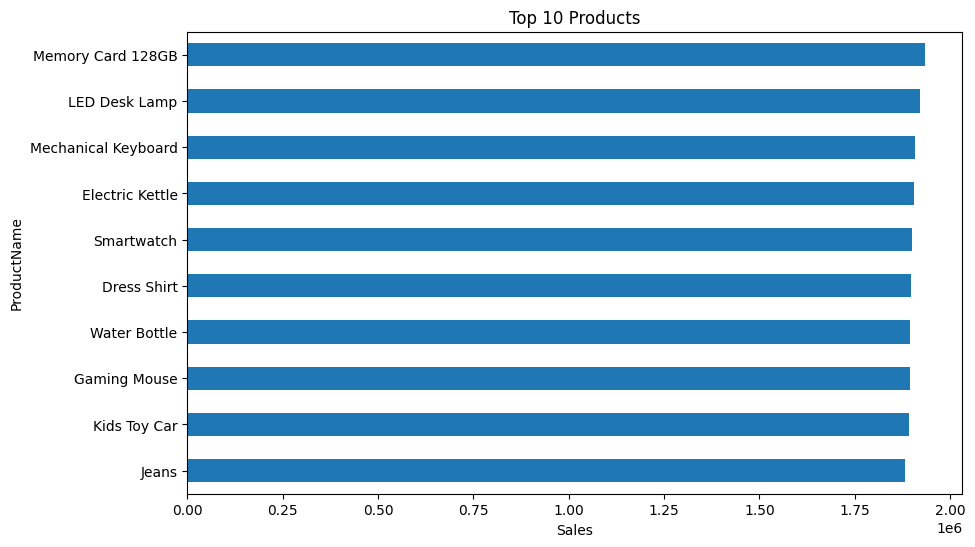

In [18]:
#Top 10 Products Chart
top10 = sales_product.head(10)

top10.plot(kind='barh', figsize=(10,6))

plt.title("Top 10 Products")

plt.xlabel("Sales")

plt.gca().invert_yaxis()

plt.show()